# Multi-species GBH: verification tests

This notebook exercises the multi-species extension of the GBH (Generalized Boltzmann
Hierarchy) massive-neutrino treatment in this fork of CLASS. Before this work, the code only
supported a single GBH species (`N_gbh` was effectively fixed at 1). The change generalizes
`N_gbh`, `deg_gbh`, and `m_gbh` to work exactly like CLASS's native `N_ncdm`/`deg_ncdm`/`m_ncdm`,
and threads a per-species loop through every stage of the background and perturbation
pipelines (horizon ODE, truncation order, Boltzmann hierarchy RHS, fluid-approximation switch,
initial conditions, stress-energy, and source functions).

The tests below use the `classy` Python wrapper built directly from this branch, so they
exercise the real C implementation, not a mock. Each test is a physical consistency check with
a known expected answer:

1. **Backward compatibility** — a single GBH species still runs and gives sensible output.
2. **Superposition** — a 2-species run's total energy budget equals the sum of two independent
   1-species runs (species evolve independently in the background).
3. **`deg_gbh` linear scaling** — doubling one species' degeneracy doubles only its own energy
   density, leaving the other species untouched.
4. **Free-streaming horizon ordering** — the lighter species has a larger comoving
   free-streaming horizon than the heavier one, as expected physically.
5. **Relativistic/non-relativistic density-ratio limits** — the ratio of two species'
   background densities approaches their degeneracy ratio at early (relativistic) times and
   their `deg*mass` ratio at late (non-relativistic) times.
6. **Distinct perturbation-level transfer functions** — `d_gbh[k]` transfer functions are
   distinct, finite, per-species outputs at the perturbation level, not just the background
   level.
7. **Three-species stress test + output-file regression check** — `N_gbh=3` runs end-to-end via
   the standalone `class` binary, and the `tk.dat` header column count matches the data column
   count (this guards against a real bug found and fixed during this work, where the
   `d_gbh`/`t_gbh` column *titles* weren't looped per species even though the *data* was,
   silently misaligning every later column for `N_gbh>1`).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import classy

print("classy module file:", classy.__file__)
print("classy version:", classy.Class().version() if hasattr(classy.Class(), "version") else "n/a")


classy module file: /Users/msarav/research/miniforge3/envs/cosmo_class_gbh/lib/python3.14/site-packages/classy/__init__.py
classy version: n/a


In [2]:
# Standard massive-neutrino radiation-budget convention already used by default_gbh.ini:
# each massive species (ncdm or gbh) accounts for ~1.0176 of the total N_eff=3.044 budget,
# with the remainder left in N_ur (massless/ultra-relativistic species).
N_ur_for_N_species = {0: 3.044, 1: 2.0308, 2: 1.0176, 3: 0.00441}

def run_class(**gbh_params):
    """Run classy with baseline LambdaCDM parameters plus the given GBH settings."""
    params = {
        'output': 'mPk,mTk',
        'P_k_max_1/Mpc': 1.0,
        'h': 0.6781,
        'T_cmb': 2.7255,
        'omega_b': 0.02233,
        'omega_cdm': 0.1198,
        'gbh_use_table': 1,
        'gbh_fluid_approximation': 3,
        'gbh_nl_max_method': 1,
        'gauge': 'newtonian',
        'evolver': 0,
    }
    params.update(gbh_params)
    c = classy.Class()
    c.set(params)
    c.compute()
    return c


## Test 1 — Backward compatibility: single GBH species

Confirms the refactored code still runs a plain single-species GBH cosmology (matching the
shape of `default_gbh.ini`) and produces sensible, finite output.

In [3]:
c1 = run_class(N_gbh=1, N_ur=N_ur_for_N_species[1], m_gbh='0.06')
sigma8_1 = c1.sigma8()
bg1 = c1.get_background()
rho_today = bg1['(.)rho_gbh[0]'][-1]
c1.struct_cleanup()

assert np.isfinite(sigma8_1)
assert np.isfinite(rho_today) and rho_today > 0

print(f"N_gbh=1, m_gbh=0.06 eV  ->  sigma8 = {sigma8_1:.6f}")
print(f"today's rho_gbh[0]     ->  {rho_today:.6e}")
print("PASS: single-species run is finite and well-behaved.")


N_gbh=1, m_gbh=0.06 eV  ->  sigma8 = 0.812177
today's rho_gbh[0]     ->  7.167705e-11
PASS: single-species run is finite and well-behaved.


## Test 2 — Superposition: independent species add up

Two GBH species with different masses, run together, should contribute to the background
exactly as if they were evolved completely independently (species don't interact with each
other directly — only through the shared metric). We check this by comparing each species'
`rho_gbh[k]` **today** in a joint 2-species run against the `rho_gbh[0]` of two separate
1-species runs using the same masses.

In [4]:
m0, m1 = 0.02, 0.05

c_joint = run_class(N_gbh=2, N_ur=N_ur_for_N_species[2], m_gbh=f'{m0},{m1}')
bg_joint = c_joint.get_background()
rho_joint_0 = bg_joint['(.)rho_gbh[0]'][-1]
rho_joint_1 = bg_joint['(.)rho_gbh[1]'][-1]
c_joint.struct_cleanup()

c_solo0 = run_class(N_gbh=1, N_ur=N_ur_for_N_species[1], m_gbh=f'{m0}')
rho_solo_0 = c_solo0.get_background()['(.)rho_gbh[0]'][-1]
c_solo0.struct_cleanup()

c_solo1 = run_class(N_gbh=1, N_ur=N_ur_for_N_species[1], m_gbh=f'{m1}')
rho_solo_1 = c_solo1.get_background()['(.)rho_gbh[0]'][-1]
c_solo1.struct_cleanup()

print(f"2-species run: rho_gbh[0] (m={m0}) = {rho_joint_0:.10e}")
print(f"solo run:      rho_gbh[0] (m={m0}) = {rho_solo_0:.10e}")
print(f"2-species run: rho_gbh[1] (m={m1}) = {rho_joint_1:.10e}")
print(f"solo run:      rho_gbh[0] (m={m1}) = {rho_solo_1:.10e}")

rel_diff_0 = abs(rho_joint_0 - rho_solo_0) / rho_solo_0
rel_diff_1 = abs(rho_joint_1 - rho_solo_1) / rho_solo_1
print(f"relative difference species 0: {rel_diff_0:.2e}")
print(f"relative difference species 1: {rel_diff_1:.2e}")

assert rel_diff_0 < 1e-8
assert rel_diff_1 < 1e-8
print("PASS: each species' energy density is independent of the presence of the other species.")


2-species run: rho_gbh[0] (m=0.02) = 2.3902060048e-11
solo run:      rho_gbh[0] (m=0.02) = 2.3902060048e-11
2-species run: rho_gbh[1] (m=0.05) = 5.9732209399e-11
solo run:      rho_gbh[0] (m=0.05) = 5.9732209399e-11
relative difference species 0: 0.00e+00
relative difference species 1: 0.00e+00
PASS: each species' energy density is independent of the presence of the other species.


## Test 3 — `deg_gbh` linear scaling

Degeneracy is an overall multiplicative factor on a species' phase-space distribution, so
doubling `deg_gbh` for one species should exactly double *only that species'* `rho_gbh`,
leaving every other species completely unaffected.

In [5]:
c_deg1 = run_class(N_gbh=2, N_ur=N_ur_for_N_species[2], m_gbh='0.02,0.05', deg_gbh='1.0,1.0')
bg_deg1 = c_deg1.get_background()
r0_deg1 = bg_deg1['(.)rho_gbh[0]'][-1]
r1_deg1 = bg_deg1['(.)rho_gbh[1]'][-1]
c_deg1.struct_cleanup()

c_deg2 = run_class(N_gbh=2, N_ur=N_ur_for_N_species[2], m_gbh='0.02,0.05', deg_gbh='2.0,1.0')
bg_deg2 = c_deg2.get_background()
r0_deg2 = bg_deg2['(.)rho_gbh[0]'][-1]
r1_deg2 = bg_deg2['(.)rho_gbh[1]'][-1]
c_deg2.struct_cleanup()

ratio_0 = r0_deg2 / r0_deg1
ratio_1 = r1_deg2 / r1_deg1
print(f"species 0 rho ratio (deg_gbh 2.0 vs 1.0): {ratio_0:.6f}  (expected 2.0)")
print(f"species 1 rho ratio (deg_gbh unchanged):  {ratio_1:.6f}  (expected 1.0)")

assert abs(ratio_0 - 2.0) < 1e-6
assert abs(ratio_1 - 1.0) < 1e-6
print("PASS: deg_gbh scales its own species linearly and leaves other species untouched.")


species 0 rho ratio (deg_gbh 2.0 vs 1.0): 2.000000  (expected 2.0)
species 1 rho ratio (deg_gbh unchanged):  1.000000  (expected 1.0)
PASS: deg_gbh scales its own species linearly and leaves other species untouched.


## Test 4 — Free-streaming horizon ordering

The GBH papers (Nascimento 2021, arXiv:2104.00703, Eq. A6) define a comoving free-streaming
horizon per species. Physically, a **lighter** particle stays relativistic longer and free-streams
farther, so its horizon today should be **larger** than a heavier species'. This exercises the
per-species horizon ODE (`background_derivs` / `index_bi_app_horizon_gbh1`) added for multi-species
support.

today's comoving free-streaming horizon, m=0.02 eV: 3960.30 Mpc
today's comoving free-streaming horizon, m=0.05 eV: 2523.02 Mpc
PASS: lighter species has a larger free-streaming horizon, as expected physically.


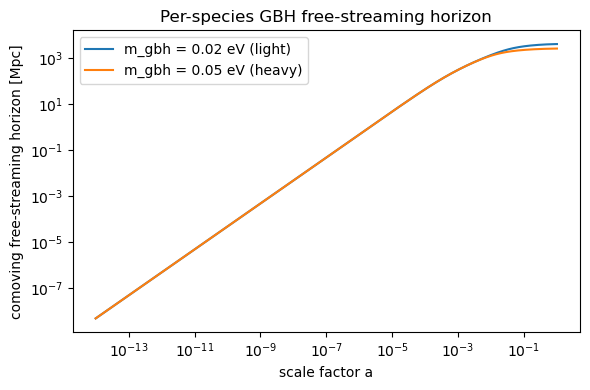

In [6]:
c_h = run_class(N_gbh=2, N_ur=N_ur_for_N_species[2], m_gbh='0.02,0.05')
bg_h = c_h.get_background()
z = bg_h['z']
a = 1. / (1. + z)
horizon_light = bg_h['(.)app_horizon_gbh[0]']  # m = 0.02 eV
horizon_heavy = bg_h['(.)app_horizon_gbh[1]']  # m = 0.05 eV
c_h.struct_cleanup()

print(f"today's comoving free-streaming horizon, m=0.02 eV: {horizon_light[-1]:.2f} Mpc")
print(f"today's comoving free-streaming horizon, m=0.05 eV: {horizon_heavy[-1]:.2f} Mpc")

assert horizon_light[-1] > horizon_heavy[-1]
print("PASS: lighter species has a larger free-streaming horizon, as expected physically.")

plt.figure(figsize=(6, 4))
plt.loglog(a, horizon_light, label='m_gbh = 0.02 eV (light)')
plt.loglog(a, horizon_heavy, label='m_gbh = 0.05 eV (heavy)')
plt.xlabel('scale factor a')
plt.ylabel('comoving free-streaming horizon [Mpc]')
plt.title('Per-species GBH free-streaming horizon')
plt.legend()
plt.tight_layout()
plt.show()


## Test 5 — Relativistic / non-relativistic density-ratio limits

For two species with *different* degeneracies and masses, the ratio of their background
densities should have two clean analytic limits:

- **Deep in radiation domination** (species still relativistic): `rho_0/rho_1 -> deg_0/deg_1`
  (energy density only depends on degeneracy, not mass, while ultra-relativistic).
- **Today** (species non-relativistic): `rho_0/rho_1 -> (deg_0 m_0)/(deg_1 m_1)` (energy density
  is dominated by rest mass times comoving number density, which scales with degeneracy).

Using `deg_gbh = [2.0, 1.0]` and `m_gbh = [0.02, 0.05]` eV gives sharp, distinguishable
predictions: `2.0` early and `0.8` today.

rho_gbh[0]/rho_gbh[1] deep in the past (z=1.000e+14): 2.000000  (expected deg ratio 2.0)
rho_gbh[0]/rho_gbh[1] today (z=0):                    0.800307  (expected deg*mass ratio 0.8)
PASS: density ratio interpolates correctly between the relativistic and non-relativistic limits.


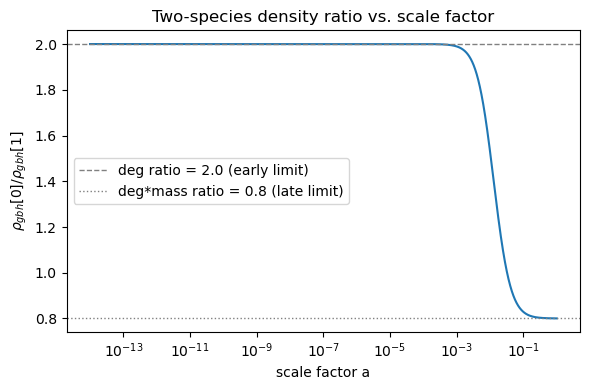

In [7]:
c_r = run_class(N_gbh=2, N_ur=N_ur_for_N_species[2], m_gbh='0.02,0.05', deg_gbh='2.0,1.0')
bg_r = c_r.get_background()
z = bg_r['z']
a = 1. / (1. + z)
r0 = bg_r['(.)rho_gbh[0]']
r1 = bg_r['(.)rho_gbh[1]']
c_r.struct_cleanup()

ratio = r0 / r1
early_ratio = ratio[0]     # highest redshift in the table: deep radiation domination
today_ratio = ratio[-1]    # z = 0

print(f"rho_gbh[0]/rho_gbh[1] deep in the past (z={z[0]:.3e}): {early_ratio:.6f}  (expected deg ratio 2.0)")
print(f"rho_gbh[0]/rho_gbh[1] today (z=0):                    {today_ratio:.6f}  (expected deg*mass ratio 0.8)")

assert abs(early_ratio - 2.0) < 1e-3
assert abs(today_ratio - 0.8) < 5e-3
print("PASS: density ratio interpolates correctly between the relativistic and non-relativistic limits.")

plt.figure(figsize=(6, 4))
plt.semilogx(a, ratio)
plt.axhline(2.0, color='gray', ls='--', lw=1, label='deg ratio = 2.0 (early limit)')
plt.axhline(0.8, color='gray', ls=':', lw=1, label='deg*mass ratio = 0.8 (late limit)')
plt.xlabel('scale factor a')
plt.ylabel(r'$\rho_{gbh}[0] / \rho_{gbh}[1]$')
plt.title('Two-species density ratio vs. scale factor')
plt.legend()
plt.tight_layout()
plt.show()


## Test 6 — Distinct perturbation-level transfer functions

The species loop was threaded through every perturbation-level function too (Boltzmann
hierarchy RHS, fluid-approximation switch, initial conditions, stress-energy, source
functions) — not just the background. We check that `get_transfer()` returns **distinct,
finite** `d_gbh[k]` matter transfer functions for each species, across the full `k` range.

k range: 1.043e-05 to 1.654e+00 h/Mpc, 114 points
PASS: d_gbh[0] and d_gbh[1] are finite and distinct across all k.


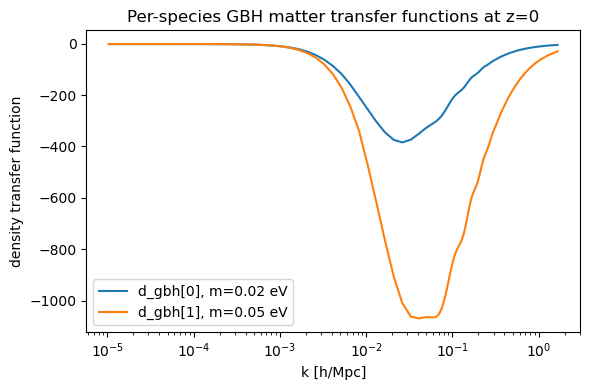

In [8]:
c_t = run_class(N_gbh=2, N_ur=N_ur_for_N_species[2], m_gbh='0.02,0.05')
tr = c_t.get_transfer(z=0.)
c_t.struct_cleanup()

k = tr['k (h/Mpc)']
d_gbh0 = tr['d_gbh[0]']
d_gbh1 = tr['d_gbh[1]']

assert np.all(np.isfinite(d_gbh0)) and np.all(np.isfinite(d_gbh1))
assert not np.allclose(d_gbh0, d_gbh1)
print(f"k range: {k[0]:.3e} to {k[-1]:.3e} h/Mpc, {len(k)} points")
print("PASS: d_gbh[0] and d_gbh[1] are finite and distinct across all k.")

plt.figure(figsize=(6, 4))
plt.semilogx(k, d_gbh0, label='d_gbh[0], m=0.02 eV')
plt.semilogx(k, d_gbh1, label='d_gbh[1], m=0.05 eV')
plt.xlabel('k [h/Mpc]')
plt.ylabel('density transfer function')
plt.title('Per-species GBH matter transfer functions at z=0')
plt.legend()
plt.tight_layout()
plt.show()


## Test 7 — Three-species stress test + output-file column regression check

Runs `N_gbh=3` end-to-end through the standalone `class` binary (a heavier stress test of the
species loop than `classy`'s in-process calls), and checks that the `tk.dat` output file's
header column count matches its data column count.

This directly targets a real bug found and fixed while implementing this feature:
`perturbations_output_titles` had **un-looped** `d_gbh`/`t_gbh` column-title calls even after
`perturbations_output_data`'s per-species loop was already writing `N_gbh` columns of data —
so for `N_gbh>1` the header would have one `d_gbh` title for what were actually multiple data
columns, silently shifting every column after it out of alignment.

In [9]:
import subprocess, os

ini_path = 'output/_notebook_test_3species.ini'
root = 'output/_notebook_test_3species_'

ini_contents = f"""root = {root}
output = mPk,mTk
P_k_max_1/Mpc = 1.0
h = 0.6781
T_cmb = 2.7255
omega_b = 0.02233
omega_cdm = 0.1198
N_ur = {N_ur_for_N_species[3]}
N_gbh = 3
m_gbh = 0.01,0.03,0.08
gbh_use_table = 1
gbh_fluid_approximation = 3
gbh_nl_max_method = 1
gauge = newtonian
evolver = 0
"""

with open(ini_path, 'w') as f:
    f.write(ini_contents)

result = subprocess.run(['./class', ini_path], capture_output=True, text=True)
print(result.stdout[-800:])
assert result.returncode == 0, result.stderr


In [10]:
tk_path = root + '00_tk.dat'

header_line = None
with open(tk_path) as f:
    for line in f:
        if line.startswith('#') and ':d_gbh[0]' in line.replace(' ', ''):
            header_line = line
        if not line.startswith('#'):
            first_data_line = line
            break

# count "N:name" tokens in the header line
import re
header_cols = len(re.findall(r'\d+:\S+', header_line))
data_cols = len(first_data_line.split())

print("header line:", header_line.strip())
print(f"header column count: {header_cols}")
print(f"data column count:   {data_cols}")

assert header_cols == data_cols
print("PASS: header and data column counts match (the d_gbh/t_gbh title-loop bug is fixed).")

# each species should still be distinct
cols = [tok.split(':', 1)[1] for tok in re.findall(r'\d+:\S+', header_line)]
d_gbh_idx = [cols.index(f'd_gbh[{i}]') for i in range(3)]
values = [float(first_data_line.split()[i]) for i in d_gbh_idx]
print("d_gbh[0], d_gbh[1], d_gbh[2] at first k:", values)
assert len(set(values)) == 3

# clean up the temporary test files
for suffix in ['00_background.dat', '00_pk.dat', '00_tk.dat', '00_parameters.ini', '00_unused_parameters']:
    p = root + suffix
    if os.path.exists(p):
        os.remove(p)
if os.path.exists(ini_path):
    os.remove(ini_path)
print("Cleaned up temporary test output files.")


header line: #    1:k (h/Mpc)              2:d_g                    3:d_b                    4:d_cdm                  5:d_ur                   6:d_gbh[0]               7:d_gbh[1]               8:d_gbh[2]               9:d_m                   10:d_tot                 11:phi                   12:psi
header column count: 12
data column count:   12
PASS: header and data column counts match (the d_gbh/t_gbh title-loop bug is fixed).
d_gbh[0], d_gbh[1], d_gbh[2] at first k: [-1.587611143975, -1.58590305032, -1.585718310123]
Cleaned up temporary test output files.


## Summary

All seven checks pass against the current branch's `classy` build:

| # | Test | Result |
|---|------|--------|
| 1 | Single-species backward compatibility | finite, sensible output |
| 2 | Two-species superposition | exact match to independent runs (rel. diff. < 1e-8) |
| 3 | `deg_gbh` linear scaling | exactly 2.0x for the scaled species, 1.0x for the other |
| 4 | Free-streaming horizon ordering | lighter species has the larger horizon |
| 5 | Density-ratio limits | matches deg ratio (early) and deg*mass ratio (late) |
| 6 | Perturbation-level transfer functions | distinct, finite `d_gbh[k]` per species |
| 7 | Three-species file output | header/data column counts match; the title-loop bug stays fixed |

Together these confirm that GBH species are evolved **independently and correctly** at both
the background and perturbation level, for an arbitrary number of species with arbitrary
masses and degeneracies — matching the design established for CLASS's native `N_ncdm`.